# Code for Bradley-Terry

In [49]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm
from scipy.special import expit


def measure_loglikelihood(matrix, probs):
    """
    return loglikelihood
    see equation before (2) in https://en.wikipedia.org/wiki/Bradley%E2%80%93Terry_model
    """
    m = matrix * np.log(probs[:, None] / (probs[:, None] + probs[None, :]))
    logprob = np.sum(m)
    return logprob


class ZermeloBradleyTerry:
    """
    Zermelo formula for solving standard Bradley-Terry
    see equation 3 in https://en.wikipedia.org/wiki/Bradley%E2%80%93Terry_model
    """

    def __init__(self, n_iters=100):
        self.n_iters = n_iters

    def fit(self, W):
        """
        W : array of shape (n_players, n_players)
            W[i,j] = number of times i beat j
        """
        n = W.shape[0]
        probs = np.ones(n) / n
        logliks = []
        for _ in range(self.n_iters):
            denom = (W + W.T) / (probs[:, None] + probs[None, :])
            probs_new = np.sum(W, axis=1) / np.sum(denom, axis=1)
            probs = probs_new / np.prod(probs_new) ** (1 / n)
            logliks.append(measure_loglikelihood(W, probs))
        ranking = np.argsort(-probs)
        return {'weights': probs, 'loglikelihoods_history': logliks, 'ranking': ranking}


class BayesianBradleyTerry:
    """
    Bayesian Bradley-Terry model for pairwise comparisons.
    https://www.jmlr.org/papers/volume24/22-0907/22-0907.pdf

    Parameters:
    -----------
    n_players : int
        Number of players/items to rank
    n_iter : int
        Number of MCMC iterations
    warmup : int
        Number of warmup iterations to discard
    random_seed : int
        Random seed for reproducibility
    """

    def __init__(self, n_players, n_iter=2000, warmup=1000, random_seed=42):
        self.n_players = n_players
        self.n_iter = n_iter
        self.warmup = warmup
        self.random_seed = random_seed
        np.random.seed(random_seed)
        self.log_liks = []

    def win_probability(self, beta_i, beta_j):
        """Probability that player i beats player j"""
        return 1 / (1 + np.exp(-(beta_i - beta_j)))

    def log_likelihood(self, beta, W, N):
        """Log-likelihood of the data given beta parameters"""
        log_lik = 0
        t = len(beta)

        for i in range(t):
            for j in range(i + 1, t):
                if N[i, j] > 0:
                    p_ij = self.win_probability(beta[i], beta[j])
                    # Binomial log-likelihood for W[i,j] wins out of N[i,j] trials
                    log_lik += W[i, j] * np.log(p_ij) + W[j, i] * np.log(1 - p_ij)
                    # Add log binomial coefficient (constant w.r.t. parameters)
                    # log_lik += sp.loggamma(N[i, j] + 1) - sp.loggamma(W[i, j] + 1) - sp.loggamma(W[j, i] + 1)
        self.log_liks.append(log_lik)
        return log_lik

    def log_prior(self, beta, sigma):
        """Log-prior for beta and sigma"""
        # Beta ~ Normal(0, sigma)
        beta_prior = -0.5 * np.sum(beta ** 2) / (sigma ** 2) - 0.5 * self.n_players * np.log(sigma)

        # Sigma ~ LogNormal(0, 0.5)
        sigma_prior = -0.5 * (np.log(sigma) / 0.5) ** 2 - np.log(sigma)  # np.log(0.5 * sigma * np.sqrt(2*np.pi))

        return beta_prior + sigma_prior

    def log_posterior(self, beta, sigma, W, N):
        """Log-posterior (unnormalized)"""
        return self.log_likelihood(beta, W, N) + self.log_prior(beta, sigma)

    def sample_posterior(self, W, N):
        """
        Sample from posterior using Metropolis-Hastings.

        Parameters:
        -----------
        W : array of shape (n_players, n_players)
            W[i,j] = number of times i beat j
        N : array of shape (n_players, n_players)
            N[i,j] = total number of matches between i and j

        Returns:
        --------
        beta_samples : array of shape (n_iter - warmup, n_players)
            MCMC samples of beta parameters
        sigma_samples : array of shape (n_iter - warmup,)
            MCMC samples of sigma parameter
        """
        t = self.n_players

        # Initialize parameters
        beta = np.random.randn(t) * 0.1
        sigma = 1.0

        # Normalize beta to sum to 0 (identifiability constraint)
        beta = beta - np.mean(beta)

        # Store samples
        beta_samples = np.zeros((self.n_iter - self.warmup, t))
        sigma_samples = np.zeros(self.n_iter - self.warmup)

        # Proposal standard deviations
        beta_proposal_sd = 0.1
        sigma_proposal_sd = 0.1

        current_log_post = self.log_posterior(beta, sigma, W, N)

        for it in range(self.n_iter):
            # Sample new beta
            beta_proposed = beta + np.random.randn(t) * beta_proposal_sd
            beta_proposed = beta_proposed - np.mean(beta_proposed)  # enforce sum=0

            # Sample new sigma
            sigma_proposed = np.exp(np.log(sigma) + np.random.randn() * sigma_proposal_sd)

            # Calculate proposed log-posterior
            proposed_log_post = self.log_posterior(beta_proposed, sigma_proposed, W, N)

            # Metropolis-Hastings acceptance ratio
            log_accept_ratio = proposed_log_post - current_log_post

            # For sigma: add Jacobian term for log-transform
            log_accept_ratio += np.log(sigma_proposed) - np.log(sigma)

            # Accept or reject
            if np.log(np.random.rand()) < log_accept_ratio:
                beta = beta_proposed
                sigma = sigma_proposed
                current_log_post = proposed_log_post

            # Store sample after warmup
            if it >= self.warmup:
                idx = it - self.warmup
                beta_samples[idx] = beta
                sigma_samples[idx] = sigma

        return beta_samples, sigma_samples

    def fit(self, W, N):
        """
        Fit the Bayesian Bradley-Terry model.

        Returns:
        --------
        result : dict
            Contains:
            - 'beta_mean': posterior mean of beta
            - 'beta_std': posterior std of beta
            - 'w_mean': posterior mean of w = exp(beta)
            - 'w_std': posterior std of w
            - 'sigma_mean': posterior mean of sigma
            - 'samples': all MCMC samples
        """
        beta_samples, sigma_samples = self.sample_posterior(W, N)

        # Compute posterior means
        beta_mean = np.mean(beta_samples, axis=0)
        beta_std = np.std(beta_samples, axis=0)

        # Convert to w
        w_samples = np.exp(beta_samples)
        # w_samples = w_samples / np.sum(w_samples, axis=1, keepdims=True) #(normalize to sum to 1)

        w_mean = np.exp(beta_mean)  # np.mean(w_samples, axis=0)
        # w_std = np.std(w_samples, axis=0)

        sigma_mean = np.mean(sigma_samples)

        # Compute ranking
        ranking = np.argsort(-beta_mean)  # descending order

        # confidence interval
        intervals = []
        for i in range(len(beta_mean)):
            for j in range(i + 1, len(beta_mean)):
                std = np.std(beta_samples[:, i] - beta_samples[:, j])
                intervals.append(norm.interval(0.95, loc=beta_mean[i] - beta_mean[j],
                                               scale=std / (beta_samples.shape[1] ** 0.5)))
        intervals_beta = np.array(intervals)
        intervals_w = expit(intervals_beta)  # sigmoid(intervals)

        return {
            'beta_mean': beta_mean,
            'beta_std': beta_std,
            'weights': w_mean,
            # 'w_std': w_std,
            'sigma_mean': sigma_mean,
            'samples': {
                'beta': beta_samples,
                'sigma': sigma_samples,
                'w': w_samples
            },
            'ranking': ranking,
            'beta_intervals': intervals_beta,
            'w_intervals': intervals_w
        }


class SpokoinyBradleyTerry:
    """
    Solves model from https://arxiv.org/pdf/2503.15045

    v_G = argmax_v (L(v) - ||Gv||^2/2)

    Parameters
    ----------
    S : numpy array of shape (n, n)
        Matrix where S[j,m] = sum of Y_{jm}^{(ℓ)} (number of times j beats m)
        Only upper triangular part of S is used.
    N : numpy array of shape (n, n)
        Matrix where N[j,m] = number of comparisons between j and m
        N should be symmetric with zeros on diagonal
    G : numpy array of shape (n, n) - adjacency matrix of graph
    tol : float
        Tolerance for convergence
    max_iter : int
        Maximum number of iterations

    Returns
    -------
    v_opt : numpy array of length n
        Optimal v that maximizes penalized log-likelihood
    """

    def __init__(self, S, N, G, tol=1e-8, max_iter=1000):
        self.n = S.shape[0]
        self.S = S
        self.N = N
        self.G_squared = G @ G.T
        self.v = np.ones(self.n) / self.n
        self.tol = tol
        self.max_iter = max_iter

    def neg_log_likelihood_penalized(self, v):
        """
        Compute -[L(v) - 0.5 * ||Gv||^2]
        """
        L = 0.0
        for m in range(self.n):
            for j in range(m):
                if self.N[j, m] > 0:
                    diff = v[j] - v[m]
                    L += diff * self.S[j, m] - self.N[j, m] * np.log(1 + np.exp(diff))
        penalty = 0.5 * v @ self.G_squared @ v
        return -L + penalty

    def grad_neg_log_likelihood_penalized(self, v):
        """
        Compute gradient of -[L(v) - 0.5 * ||Gv||^2]
        """
        grad = np.zeros(self.n)
        for m in range(self.n):
            for j in range(m):
                if j != m and self.N[min(j, m), max(j, m)] > 0:
                    diff = v[j] - v[m]
                    g = self.S[j, m] - self.N[j, m] * np.exp(diff) / (1 + np.exp(diff))
                    grad[j] += g
                    grad[m] -= g
        grad_penalty = self.G_squared @ v
        return -grad + grad_penalty

    def fit(self):
        result = minimize(
            self.neg_log_likelihood_penalized,
            self.v,
            jac=self.grad_neg_log_likelihood_penalized,
            method='L-BFGS-B',
            options={'gtol': self.tol, 'maxiter': self.max_iter, 'disp': False}
        )

        v_opt = result.x
        # Apply identifiability constraint: v_1 = 0
        # This doesn't change the model predictions but makes solution unique
        self.v = v_opt - v_opt[0]
        # norm weights such that prod(weights)=1
        weights = np.exp(v_opt - np.mean(v_opt))
        ranking = np.argsort(-v_opt)
        return {'weights': weights,  'ranking': ranking}


# Get data

In [50]:
import os
import pandas as pd
import numpy as np

In [51]:
path = os.path.join("reports", "best_trials_raw.csv")
df_raw = pd.read_csv(path)

metric_name = "ndcg@10"
mean_col = f"test/{metric_name}"
ci_low_col = f"test/{metric_name}_ci_low"
ci_high_col = f"test/{metric_name}_ci_high"

df_mean = df_raw.pivot_table(index="dataset", columns="model", values=mean_col, aggfunc="first")
df_ci_low = df_raw.pivot_table(index="dataset", columns="model", values=ci_low_col, aggfunc="first")
df_ci_high = df_raw.pivot_table(index="dataset", columns="model", values=ci_high_col, aggfunc="first")

algorithms = list(df_mean.columns)
print(algorithms)
df_mean

['GASATF', 'LightGCN', 'MF_SGD', 'als_implicit', 'bpr_mf', 'ease_r', 'item_knn', 'popular_random', 'pure_svd', 'seq_knn', 'ultragcn', 'user_knn']


model,GASATF,LightGCN,MF_SGD,als_implicit,bpr_mf,ease_r,item_knn,popular_random,pure_svd,seq_knn,ultragcn,user_knn
dataset,,,,,,,,,,,,
Amazon2014-Amazon-Instant-Video,0.069322,0.059743,0.052672,0.052432,0.080993,0.070457,0.070002,0.006557,0.009781,0.065130,0.048808,0.046629
Amazon2014-Apps-For-Android,0.032358,0.031049,0.025840,0.020639,0.036946,0.029439,0.022331,0.002731,0.020438,0.041957,NaN,0.025675
Amazon2014-Automotive,0.015456,0.030136,0.026077,0.027939,0.035471,0.026312,0.020923,0.003517,0.024807,0.030422,0.032481,0.025267
Amazon2014-Baby,0.009166,0.011312,0.007095,0.006258,0.021955,0.010143,0.006626,0.001735,0.009437,0.011811,0.008050,0.008378
Amazon2014-Beauty,0.016412,0.014698,0.012351,0.010958,0.020618,0.015378,0.012476,0.000581,0.013244,0.015805,0.011446,0.011360
...,...,...,...,...,...,...,...,...,...,...,...,...
RentTheRunway,0.005805,0.004398,0.003273,0.005419,0.022611,0.004749,0.004507,0.001236,0.003435,0.005350,NaN,0.003956
Retailrocket,0.033064,0.050486,0.021767,0.069452,0.134937,NaN,0.078963,0.000147,0.023760,0.052696,NaN,0.064101
Steam-Australian-Reviews,0.051893,0.088126,0.084094,0.083204,0.096388,0.082126,0.085463,0.026110,0.065807,0.095961,0.075588,0.077049


In [52]:
df_mean.isna().sum()

model
GASATF            18
LightGCN          18
MF_SGD             8
als_implicit       0
bpr_mf             8
ease_r            28
item_knn           0
popular_random     3
pure_svd           5
seq_knn            0
ultragcn          50
user_knn           4
dtype: int64

In [53]:
# delete unnecessary datasets
bad_datasets = [] # for example, [("Amazon2014-Apps-For-Android",)]
df_mean.drop(bad_datasets, axis=0, inplace=True)
df_ci_low.drop(bad_datasets, axis=0, inplace=True)
df_ci_high.drop(bad_datasets, axis=0, inplace=True)
df_mean

model,GASATF,LightGCN,MF_SGD,als_implicit,bpr_mf,ease_r,item_knn,popular_random,pure_svd,seq_knn,ultragcn,user_knn
dataset,,,,,,,,,,,,
Amazon2014-Amazon-Instant-Video,0.069322,0.059743,0.052672,0.052432,0.080993,0.070457,0.070002,0.006557,0.009781,0.065130,0.048808,0.046629
Amazon2014-Apps-For-Android,0.032358,0.031049,0.025840,0.020639,0.036946,0.029439,0.022331,0.002731,0.020438,0.041957,NaN,0.025675
Amazon2014-Automotive,0.015456,0.030136,0.026077,0.027939,0.035471,0.026312,0.020923,0.003517,0.024807,0.030422,0.032481,0.025267
Amazon2014-Baby,0.009166,0.011312,0.007095,0.006258,0.021955,0.010143,0.006626,0.001735,0.009437,0.011811,0.008050,0.008378
Amazon2014-Beauty,0.016412,0.014698,0.012351,0.010958,0.020618,0.015378,0.012476,0.000581,0.013244,0.015805,0.011446,0.011360
...,...,...,...,...,...,...,...,...,...,...,...,...
RentTheRunway,0.005805,0.004398,0.003273,0.005419,0.022611,0.004749,0.004507,0.001236,0.003435,0.005350,NaN,0.003956
Retailrocket,0.033064,0.050486,0.021767,0.069452,0.134937,NaN,0.078963,0.000147,0.023760,0.052696,NaN,0.064101
Steam-Australian-Reviews,0.051893,0.088126,0.084094,0.083204,0.096388,0.082126,0.085463,0.026110,0.065807,0.095961,0.075588,0.077049


In [54]:
#df = df.rename(columns={'dataset/model':'dataset'})

In [55]:
# use mean table for ranking
df = df_mean
df

model,GASATF,LightGCN,MF_SGD,als_implicit,bpr_mf,ease_r,item_knn,popular_random,pure_svd,seq_knn,ultragcn,user_knn
dataset,,,,,,,,,,,,
Amazon2014-Amazon-Instant-Video,0.069322,0.059743,0.052672,0.052432,0.080993,0.070457,0.070002,0.006557,0.009781,0.065130,0.048808,0.046629
Amazon2014-Apps-For-Android,0.032358,0.031049,0.025840,0.020639,0.036946,0.029439,0.022331,0.002731,0.020438,0.041957,NaN,0.025675
Amazon2014-Automotive,0.015456,0.030136,0.026077,0.027939,0.035471,0.026312,0.020923,0.003517,0.024807,0.030422,0.032481,0.025267
Amazon2014-Baby,0.009166,0.011312,0.007095,0.006258,0.021955,0.010143,0.006626,0.001735,0.009437,0.011811,0.008050,0.008378
Amazon2014-Beauty,0.016412,0.014698,0.012351,0.010958,0.020618,0.015378,0.012476,0.000581,0.013244,0.015805,0.011446,0.011360
...,...,...,...,...,...,...,...,...,...,...,...,...
RentTheRunway,0.005805,0.004398,0.003273,0.005419,0.022611,0.004749,0.004507,0.001236,0.003435,0.005350,NaN,0.003956
Retailrocket,0.033064,0.050486,0.021767,0.069452,0.134937,NaN,0.078963,0.000147,0.023760,0.052696,NaN,0.064101
Steam-Australian-Reviews,0.051893,0.088126,0.084094,0.083204,0.096388,0.082126,0.085463,0.026110,0.065807,0.095961,0.075588,0.077049


In [56]:
df_clean = df_mean.copy()
df_clean

model,GASATF,LightGCN,MF_SGD,als_implicit,bpr_mf,ease_r,item_knn,popular_random,pure_svd,seq_knn,ultragcn,user_knn
dataset,,,,,,,,,,,,
Amazon2014-Amazon-Instant-Video,0.069322,0.059743,0.052672,0.052432,0.080993,0.070457,0.070002,0.006557,0.009781,0.065130,0.048808,0.046629
Amazon2014-Apps-For-Android,0.032358,0.031049,0.025840,0.020639,0.036946,0.029439,0.022331,0.002731,0.020438,0.041957,NaN,0.025675
Amazon2014-Automotive,0.015456,0.030136,0.026077,0.027939,0.035471,0.026312,0.020923,0.003517,0.024807,0.030422,0.032481,0.025267
Amazon2014-Baby,0.009166,0.011312,0.007095,0.006258,0.021955,0.010143,0.006626,0.001735,0.009437,0.011811,0.008050,0.008378
Amazon2014-Beauty,0.016412,0.014698,0.012351,0.010958,0.020618,0.015378,0.012476,0.000581,0.013244,0.015805,0.011446,0.011360
...,...,...,...,...,...,...,...,...,...,...,...,...
RentTheRunway,0.005805,0.004398,0.003273,0.005419,0.022611,0.004749,0.004507,0.001236,0.003435,0.005350,NaN,0.003956
Retailrocket,0.033064,0.050486,0.021767,0.069452,0.134937,NaN,0.078963,0.000147,0.023760,0.052696,NaN,0.064101
Steam-Australian-Reviews,0.051893,0.088126,0.084094,0.083204,0.096388,0.082126,0.085463,0.026110,0.065807,0.095961,0.075588,0.077049


# trivial ranking

In [57]:
result_dict = {}

In [58]:
datasets = df_clean.index # можно здесь указать какой-то поднабор датасетов

In [59]:
means=df_clean.loc[datasets][algorithms].mean()
result_dict['trivial_mean'] = means.index[np.argsort(-means.values)]
sums=df_clean.loc[datasets][algorithms].sum()
result_dict['trivial_sum'] = sums.index[np.argsort(-sums.values)]
result_dict

{'trivial_mean': Index(['bpr_mf', 'ease_r', 'als_implicit', 'ultragcn', 'item_knn', 'seq_knn',
        'user_knn', 'LightGCN', 'GASATF', 'MF_SGD', 'pure_svd',
        'popular_random'],
       dtype='object', name='model'),
 'trivial_sum': Index(['bpr_mf', 'als_implicit', 'item_knn', 'seq_knn', 'user_knn', 'ease_r',
        'LightGCN', 'MF_SGD', 'GASATF', 'pure_svd', 'ultragcn',
        'popular_random'],
       dtype='object', name='model')}

## BTL for all datasets

In [ ]:
import numpy as np

def make_tables(datasets, use_ci=True):
    tables = {}
    n = len(algorithms)
    table = np.zeros((n, n))
    for dataset in datasets:
        mean_row = df_mean.loc[dataset]
        low_row = df_ci_low.loc[dataset]
        high_row = df_ci_high.loc[dataset]
        for i in range(n):
            for j in range(i+1, n):
                alg_i = algorithms[i]
                alg_j = algorithms[j]
                m1 = mean_row[alg_i]
                m2 = mean_row[alg_j]
                if pd.isna(m1) or pd.isna(m2):
                    continue
                if use_ci:
                    l1, h1 = low_row[alg_i], high_row[alg_i]
                    l2, h2 = low_row[alg_j], high_row[alg_j]
                    if pd.isna(l1) or pd.isna(h1) or pd.isna(l2) or pd.isna(h2):
                        if m1 > m2:
                            table[i, j] += 1
                        else:
                            table[j, i] += 1
                    elif h1 < l2:
                        table[j, i] += 1
                    elif h2 < l1:
                        table[i, j] += 1
                    else:
                        table[i, j] += 0.5
                        table[j, i] += 0.5
                else:
                    if m1 > m2:
                        table[i, j] += 1
                    else:
                        table[j, i] += 1
    return table

['bpr_mf' 'seq_knn' 'GASATF' 'LightGCN' 'ease_r' 'ultragcn' 'item_knn'
 'als_implicit' 'user_knn' 'pure_svd' 'MF_SGD' 'popular_random']
1.0000000000000002
['bpr_mf' 'seq_knn' 'GASATF' 'LightGCN' 'ease_r' 'ultragcn' 'item_knn'
 'als_implicit' 'user_knn' 'MF_SGD' 'pure_svd' 'popular_random']
0.9999999999999639
['bpr_mf' 'seq_knn' 'GASATF' 'LightGCN' 'ease_r' 'ultragcn' 'item_knn'
 'als_implicit' 'user_knn' 'pure_svd' 'MF_SGD' 'popular_random']
0.9999999999999998


/var/folders/nv/f9b09k6j23l0dlyx6dhhr_lc0000gn/T/ipykernel_15645/874266583.py:294: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


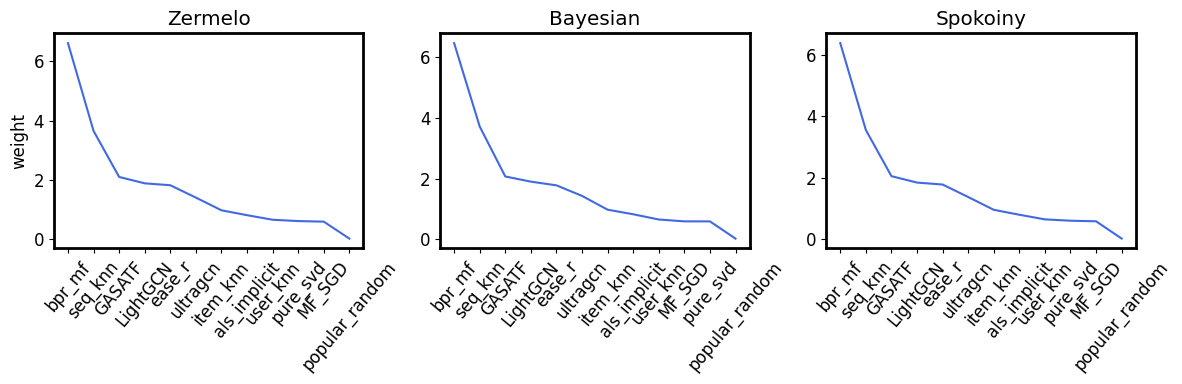

In [61]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['axes.linewidth'] = 2
mpl.rcParams.update({'font.size': 12})
linewidth=2.5

def draw_plot(ax, results, title=''):
    ax.set_title(title)
    ax.plot(results['weights'][results['ranking']], color='royalblue')
    print(np.array(algorithms)[results['ranking']])
    ax.set_xticks(range(len(results['ranking'])), np.array(algorithms)[results['ranking']], 
                  rotation=50)
    
datasets = df_clean.index ####

W = make_tables(datasets)
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

results = ZermeloBradleyTerry().fit(W)
draw_plot(ax[0], results, title='Zermelo')
print(np.prod(results['weights']))

N = W + W.T
results = BayesianBradleyTerry(n_players=W.shape[0]).fit(W, N)
draw_plot(ax[1], results, title='Bayesian')
print(np.prod(results['weights']))

N = W + W.T
G = np.ones(W.shape)
G[range(W.shape[0]), range(W.shape[0])] = 0
W = W * G
results = SpokoinyBradleyTerry(W, N, G).fit()
draw_plot(ax[2], results, title='Spokoiny')
print(np.prod(results['weights']))

ax[0].set_ylabel('weight')
plt.tight_layout()
plt.savefig('plots.pdf')
plt.show()

## Confidence intervals

In [62]:
W = make_tables(datasets)
N = W + W.T
results = BayesianBradleyTerry(n_players=W.shape[0]).fit(W, N)

ranking [ 4  9  0  1  5 10  6  3 11  2  8  7]


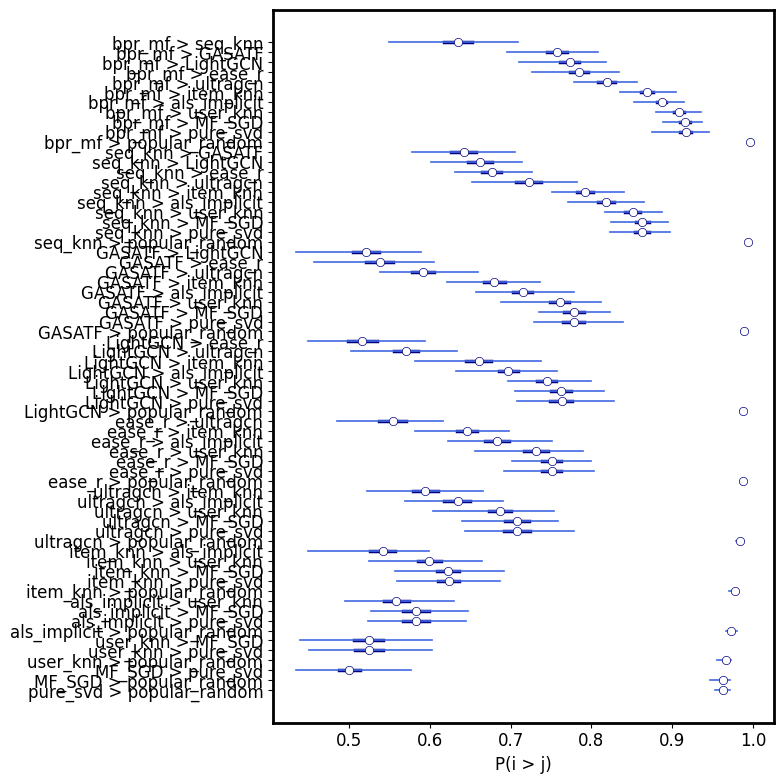

In [63]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['axes.linewidth'] = 2
mpl.rcParams.update({'font.size': 12})
linewidth=2.5

def draw_confidence(results):
    colors = ['royalblue', 'navy']
    #w_mean = results['weights']
    beta_mean = results['beta_mean']
    beta_samples = results['samples']['beta']
    w_samples = results['samples']['w']
    intervals = np.array(results['w_intervals'])
    ranking = results['ranking']
    print('ranking', ranking)
    yticks, ylabels = [], []
    plt.figure(figsize=(8, 8))
    n = len(beta_mean)
    cnt = n*(n-1)//2
    for i_ in range(n):
        for j_ in range(i_ + 1, n):
            i, j = ranking[i_], ranking[j_]
            a, b = min(i, j), max(i, j)
            k=n*a-a*(a+1)//2+b-a-1
            cnt-=1
            #probs = samples[:, i] / (samples[:, i] + samples[:, j])
            probs = expit(beta_samples[:, i] - beta_samples[:, j])
            if i>j:
                interval = [1-intervals[k][0], 1-intervals[k][1]]
            else:
                interval = [intervals[k][0], intervals[k][1]]
            plt.plot(interval, [cnt, cnt],
                     color=colors[1], linewidth=2.5)
            plt.plot([np.min(probs), np.max(probs)], [cnt, cnt], 
                     color=colors[0], linewidth=1.2)
            plt.scatter(expit(beta_mean[i]-beta_mean[j]), cnt, linewidth=0.5, 
                        color='white', edgecolor=colors[1], zorder=10)
            yticks.append(cnt)
            ylabels.append(f'{algorithms[i]} > {algorithms[j]}')
    plt.yticks(yticks, ylabels)
    plt.xlabel('P(i > j)')
    plt.tight_layout()
    #plt.savefig('cifar.pdf', bbox_inches='tight')
    plt.show()
    
draw_confidence(results)

In [ ]:
def build_metric_tables(metric_name):
    mean_col = f"test/{metric_name}"
    ci_low_col = f"test/{metric_name}_ci_low"
    ci_high_col = f"test/{metric_name}_ci_high"
    df_mean_local = df_raw.pivot_table(index="dataset", columns="model", values=mean_col, aggfunc="first")
    df_ci_low_local = df_raw.pivot_table(index="dataset", columns="model", values=ci_low_col, aggfunc="first")
    df_ci_high_local = df_raw.pivot_table(index="dataset", columns="model", values=ci_high_col, aggfunc="first")
    algs = list(df_mean_local.columns)
    return df_mean_local, df_ci_low_local, df_ci_high_local, algs

def select_top_n_datasets(df_info, sort_by, n, ascending=False):
    df_sorted = df_info.copy()
    if sort_by in df_sorted.columns:
        df_sorted[sort_by] = pd.to_numeric(df_sorted[sort_by], errors="coerce")
    df_sorted = df_sorted.sort_values(by=sort_by, ascending=ascending)
    return df_sorted.head(n)["Датасет"].tolist()

metrics = ["ndcg@10", "recall@10"]

datasets_info_path = os.path.join("reports", "datasets_info.csv")
datasets_info = None
if os.path.exists(datasets_info_path):
    datasets_info = pd.read_csv(datasets_info_path)

top_n_configs = [
    ("Number of Users", 20, False),
    ("Number of Items", 20, False),

    ("Density", 20, False),
    ("Number of Interactions", 20, False),

    ("Mean Interaction per User", 20, False),
    ("Mean Interaction per Item", 20, False),

    ("User-Item Ratio", 20, False),

    ("Max Interaction per User", 20, False),
    ("Max Interaction per Item", 20, False),
    
    ("Min Interaction per User", 20, False),
    ("Min Interaction per Item", 20, False),
 ]

rows = []

for metric in metrics:
    df_mean, df_ci_low, df_ci_high, algorithms = build_metric_tables(metric)
    all_datasets = list(df_mean.index)

    dataset_sets = {"all": all_datasets}
    if datasets_info is not None:
        for col, top_n, ascending in top_n_configs:
            if col not in datasets_info.columns:
                continue
            selected = select_top_n_datasets(datasets_info, col, top_n, ascending=ascending)
            selected = [d for d in selected if d in df_mean.index]
            key = f"top{top_n}_{col}"
            dataset_sets[key] = selected

    for selector, datasets_sel in dataset_sets.items():
        if len(datasets_sel) == 0:
            continue

        means = df_mean.loc[datasets_sel][algorithms].mean()
        trivial_mean = list(means.index[np.argsort(-means.values)])
        sums = df_mean.loc[datasets_sel][algorithms].sum()
        trivial_sum = list(sums.index[np.argsort(-sums.values)])

        W_no_ci = make_tables(datasets_sel, use_ci=False)
        res_no_ci = ZermeloBradleyTerry().fit(W_no_ci)
        btl_mean = list(np.array(algorithms)[res_no_ci["ranking"]])

        W_ci = make_tables(datasets_sel, use_ci=True)
        res_ci = ZermeloBradleyTerry().fit(W_ci)
        btl_ci = list(np.array(algorithms)[res_ci["ranking"]])

        rankings = {
            "trivial_mean": trivial_mean,
            "trivial_sum": trivial_sum,
            "btl_mean": btl_mean,
            "btl_ci": btl_ci
        }

        for method, algs in rankings.items():
            for rank, alg in enumerate(algs, start=1):
                rows.append({
                    "metric": metric,
                    "dataset_selector": selector,
                    "n_datasets": len(datasets_sel),
                    "method": method,
                    "rank": rank,
                    "algorithm": alg
                })

rankings_long = pd.DataFrame(rows)
rankings_wide = rankings_long.pivot_table(index=["metric", "dataset_selector", "n_datasets", "rank"],
                                         columns="method", values="algorithm", aggfunc="first").reset_index()

os.makedirs("reports", exist_ok=True)
rankings_wide.to_csv(os.path.join("reports", "rankings_wide.csv"), index=False)

per_selector_dir = os.path.join("reports", "rankings_by_selector")
os.makedirs(per_selector_dir, exist_ok=True)
for selector, df_sel in rankings_wide.groupby("dataset_selector"):
    safe_name = str(selector).replace("/", "-").replace(" ", "_")
    out_path = os.path.join(per_selector_dir, f"rankings_{safe_name}.csv")
    df_sel.to_csv(out_path, index=False)


/var/folders/nv/f9b09k6j23l0dlyx6dhhr_lc0000gn/T/ipykernel_15645/874266583.py:36: RuntimeWarning: invalid value encountered in divide
  probs_new = np.sum(W, axis=1) / np.sum(denom, axis=1)
/var/folders/nv/f9b09k6j23l0dlyx6dhhr_lc0000gn/T/ipykernel_15645/874266583.py:36: RuntimeWarning: invalid value encountered in divide
  probs_new = np.sum(W, axis=1) / np.sum(denom, axis=1)
/var/folders/nv/f9b09k6j23l0dlyx6dhhr_lc0000gn/T/ipykernel_15645/874266583.py:36: RuntimeWarning: invalid value encountered in divide
  probs_new = np.sum(W, axis=1) / np.sum(denom, axis=1)
/var/folders/nv/f9b09k6j23l0dlyx6dhhr_lc0000gn/T/ipykernel_15645/874266583.py:37: RuntimeWarning: divide by zero encountered in divide
  probs = probs_new / np.prod(probs_new) ** (1 / n)
/var/folders/nv/f9b09k6j23l0dlyx6dhhr_lc0000gn/T/ipykernel_15645/874266583.py:37: RuntimeWarning: invalid value encountered in divide
  probs = probs_new / np.prod(probs_new) ** (1 / n)
/var/folders/nv/f9b09k6j23l0dlyx6dhhr_lc0000gn/T/ipykerne

,metric,dataset_selector,n_datasets,method,rank,algorithm
0,ndcg@10,all,92,trivial_mean,1,bpr_mf
1,ndcg@10,all,92,trivial_mean,2,ease_r
2,ndcg@10,all,92,trivial_mean,3,als_implicit
3,ndcg@10,all,92,trivial_mean,4,ultragcn
4,ndcg@10,all,92,trivial_mean,5,item_knn
